# Pandas Basics

**Goal:** Learn the core building blocks of Pandas — `Series` and `DataFrame` — and how to load, inspect, filter, and summarize real data.

**Why it matters:** Every ML pipeline starts with data. Pandas is the standard tool for loading and shaping tabular data before it ever reaches a model. If you can't manipulate data confidently, no model will save you.

**Dataset:** `titanic` (loaded from a public URL — no local file needed)

---

# Pandas Basics

**Goal:** Learn the core building blocks of Pandas — `Series` and `DataFrame` — and how to load, inspect, filter, and summarize real data.

**Why it matters:** Every ML pipeline starts with data. Pandas is the standard tool for loading and shaping tabular data before it ever reaches a model. If you can't manipulate data confidently, no model will save you.

**Dataset:** `titanic` (loaded from a public URL — no local file needed)

---

In [63]:
import pandas as pd 
import numpy as np 

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

pandas : 2.3.3
numpy  : 2.4.0


In [64]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("shape :",df.shape)

shape : (891, 12)


##  First Look

Always inspect the first and last rows before doing anything. This catches obvious issues (wrong separator, missing headers, weird encoding).

In [65]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


##  Structure & Types

`info()` gives us column names, non-null counts, and dtypes — a one-shot health check.


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Statistical Summary

`describe()` gives count, mean, std, min, quartiles, max for numeric columns.

In [68]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [69]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


##  Selecting Columns

Two ways: dot notation (`df.Age`) and bracket notation (`df["Age"]`).  
**Always prefer brackets** — they work with spaces, special chars, and variable names.

In [70]:
ages = df["Age"]
print(type(ages))
ages.head()

<class 'pandas.core.series.Series'>


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

In [71]:
subset = df[["Name", "Age", "Survived"]]
subset.head()

,Name,Age,Survived
0,"Braund, Mr. Owen Harris",22.0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1
2,"Heikkinen, Miss. Laina",26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1
4,"Allen, Mr. William Henry",35.0,0


## Filtering Rows (Boolean Indexing)

This is the single most-used Pandas skill. Build a boolean mask, then use it to slice.

In [72]:

mask = df["Age"] < 20


younger_than_20 = df[mask]
print("Rows under 20 :", younger_than_20.shape[0] ,"of all :" , df["Age"].shape[0] )
younger_than_20.head(3)

Rows under 20 : 164 of all : 891


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S


In [73]:
survived_men = df[(df["Sex"] == "female") & (df["Survived"]== 1)]
print("men who survived:", survived_men.shape[0])

men who survived: 233


##  Handling Missing Values

Missing data breaks models. First: **measure it**. Then decide. (Nan)

In [74]:
# for each column 
missing = df.isnull().sum()
# Age Nan Number = 177 , Cabin Nan Number = 687 ,Embarked Nan Number = 2
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Cabin       687
Age         177
Embarked      2
dtype: int64


In [75]:
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct.round(2))


Cabin       77.10
Age         19.87
Embarked     0.22
dtype: float64


i think it is better to drop cabin and PassengerId,
##  Grouping & Aggregation

`groupby()` = split → apply → combine. The heart of EDA.

In [ ]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [77]:
df.groupby("Pclass")["Survived"].agg(["mean", "count"])

,mean,count
Pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


In [78]:
df.groupby(["Sex", "Pclass"])["Survived"].mean().round(3)

Sex     Pclass
female  1         0.968
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: Survived, dtype: float64

##  Quick Visualization

Pandas has built-in plotting (backed by Matplotlib). Perfect for a fast sanity check.

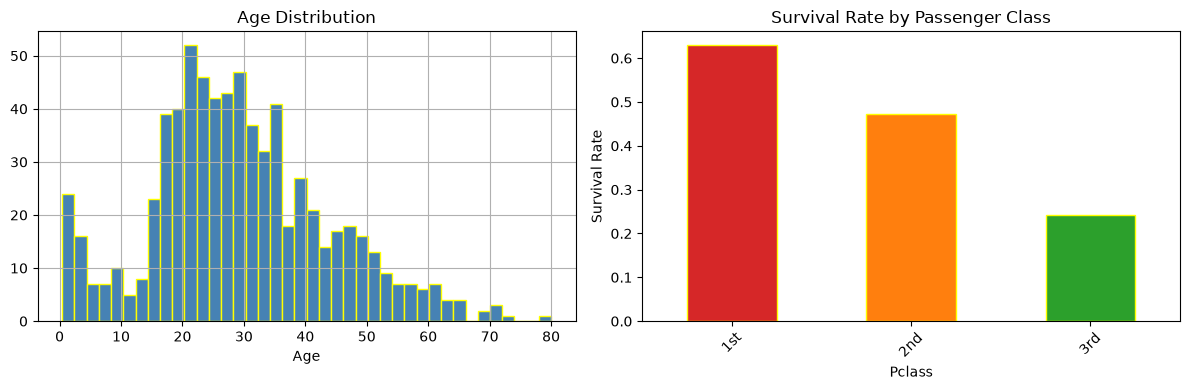

In [87]:
import matplotlib.pyplot as plt 
fig , axes = plt.subplots(1, 2, figsize=(12 , 4))
df["Age"].dropna().hist(ax=axes[0], bins=40, color="steelblue", edgecolor="yellow")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
df.groupby("Pclass")["Survived"].mean().plot(
    kind="bar", ax=axes[1], color=["#d62728", "#ff7f0e", "#2ca02c"], edgecolor="yellow"
)
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")
axes[1].set_xticklabels(["1st", "2nd", "3rd"] , rotation=45)

plt.tight_layout()
plt.show()

##  What We Learned

- **Series vs DataFrame**: one column vs full table.
- **Inspection first**: always `head()`, `info()`, `describe()` before anything else.
- **Boolean masks** are how you filter — combine with `&`/`|`, wrap each condition in `()`.
- **Missing values**: measure count *and* percentage before deciding.
- **groupby().agg()** is the workhorse of EDA.
- **Feature engineering** starts with simple combinations (FamilySize, IsAlone).

## 🚀 Next

→ [02-data-cleaning.ipynb](./02-data-cleaning.ipynb): handle missing values, drop outliers, fix dtypes.